In [39]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
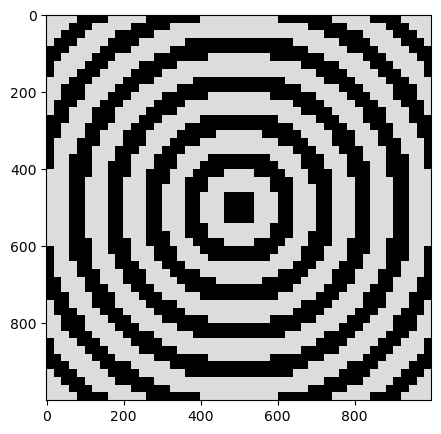


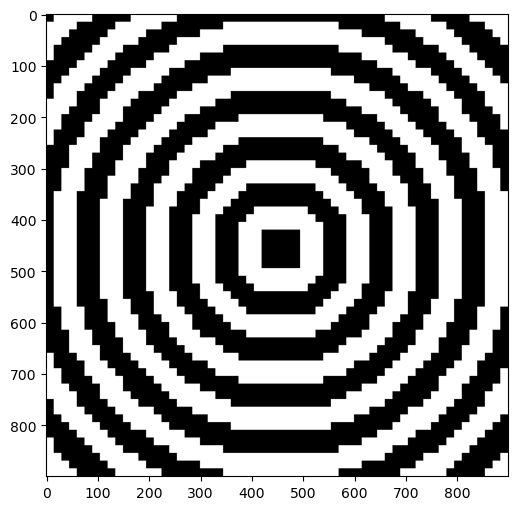

True

In [128]:
base = np.zeros((60, 60), dtype=np.uint8)

for i in range(60):
    for j in range(60):
        distancia = np.sqrt((i - 30)**2 + (j - 30)**2)
        if (distancia // 3) % 2 != 0:
            base[i, j] = 225

diana = cv2.resize(base, (900, 900), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(6, 6))
plt.imshow(diana, cmap='gray')
plt.show()

cv2.imwrite('diana.png', diana)

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
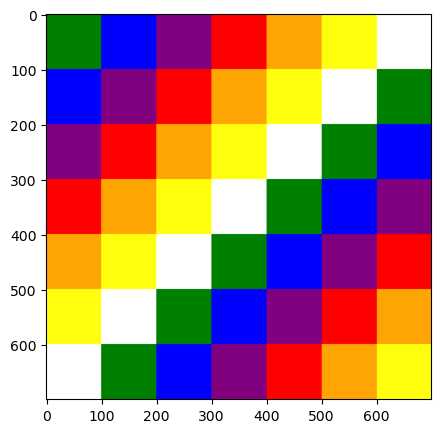

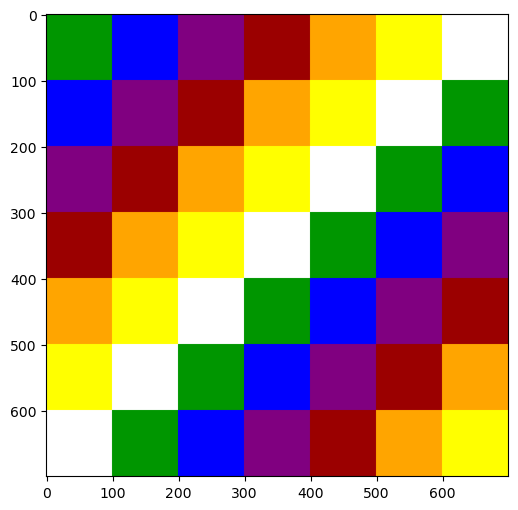

True

In [134]:
wiphala = np.zeros((700, 700, 3), dtype=np.uint8)

colores = [
    (0, 150, 0),
    (255, 0, 0),
    (128, 0, 128),
    (0, 0, 155),
    (0, 165, 255),
    (0, 255, 255),
    (255, 255, 255)
]

for i in range(7):
    for j in range(7):
        color = colores[(i + j) % 7]
        wiphala[i*100:(i+1)*100, j*100:(j+1)*100] = color

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(wiphala, cv2.COLOR_BGR2RGB))
plt.show()

cv2.imwrite('wiphala.png', wiphala)

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

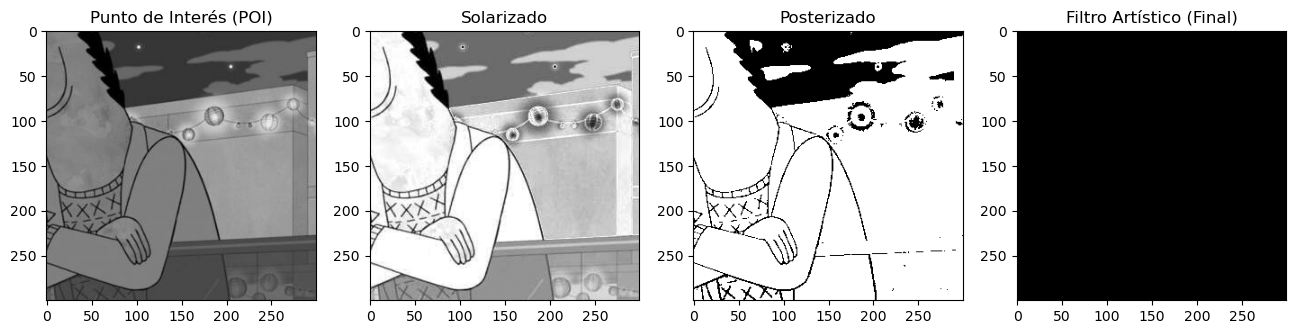

Imágenes guardadas con marca de tiempo: 20260401_102031


In [ ]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import datetime

img = cv2.imread('imagen1.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    alto, ancho = img.shape
    t_recorte = 300
    
    y = random.randint(0, alto - t_recorte)
    x = random.randint(0, ancho - t_recorte)
    
    recorte = img[y:y+t_recorte, x:x+t_recorte]
    

    solarizado = np.where(recorte > 127, 255 - recorte, recorte).astype(np.uint8)
    
    posterizado = (solarizado // 64) * 64

    _, arte = cv2.threshold(posterizado, 100, 255, cv2.THRESH_BINARY)


    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(recorte, cmap='gray')
    axs[0].set_title('Punto de Interés (POI)')
    axs[1].imshow(solarizado, cmap='gray')
    axs[1].set_title('Solarizado')
    axs[2].imshow(posterizado, cmap='gray')
    axs[2].set_title('Posterizado')
    axs[3].imshow(arte, cmap='gray')
    axs[3].set_title('Filtro Artístico (Final)')
    plt.show()
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    cv2.imwrite(f'p3_01_poi_{stamp}.png', recorte)
    cv2.imwrite(f'p3_02_solarizado_{stamp}.png', solarizado)
    cv2.imwrite(f'p3_03_posterizado_{stamp}.png', posterizado)
    cv2.imwrite(f'p3_04_arte_final_{stamp}.png', arte)
    
    print(f"Imágenes guardadas: {stamp}")
else:
    print("Error: No se pudod cargar 'imagen1.jpg'.")

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

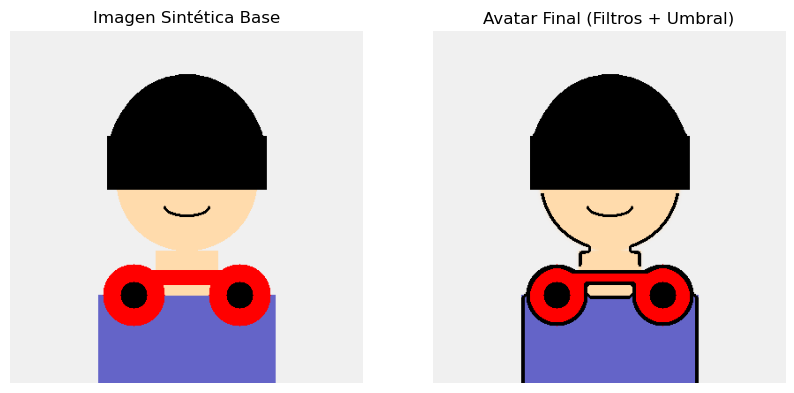

Avatar guardado como 'ej4_avatar_generado.jpg'


In [ ]:

ancho_av, alto_av = 400, 400
img_base_avatar = np.zeros((alto_av, ancho_av, 3), dtype=np.uint8)
img_base_avatar[:, :] = (240, 240, 240) # Fondo gris muy claro


negro_av = (0, 0, 0)
piel_av = (172, 219, 255) 
rojo_av = (0, 0, 255)
camiseta_av = (200, 100, 100) 


cv2.rectangle(img_base_avatar, (100, 300), (300, 400), camiseta_av, -1)


cv2.rectangle(img_base_avatar, (165, 250), (235, 300), piel_av, -1)


cv2.circle(img_base_avatar, (200, 170), 80, piel_av, -1)


cv2.ellipse(img_base_avatar, (200, 150), (90, 100), 0, 180, 360, negro_av, -1) 
cv2.rectangle(img_base_avatar, (110, 120), (290, 180), negro_av, -1) 


cv2.line(img_base_avatar, (150, 280), (250, 280), rojo_av, 15)

cv2.circle(img_base_avatar, (140, 300), 35, rojo_av, -1) 
cv2.circle(img_base_avatar, (260, 300), 35, rojo_av, -1) 

cv2.circle(img_base_avatar, (140, 300), 15, negro_av, -1)
cv2.circle(img_base_avatar, (260, 300), 15, negro_av, -1)


cv2.circle(img_base_avatar, (170, 160), 5, negro_av, -1) # Ojo Izq
cv2.circle(img_base_avatar, (230, 160), 5, negro_av, -1) # Ojo Der
cv2.ellipse(img_base_avatar, (200, 200), (25, 10), 0, 0, 180, negro_av, 2) # Sonrisa


img_color_suave = cv2.bilateralFilter(img_base_avatar, d=9, sigmaColor=75, sigmaSpace=75)


img_gris = cv2.cvtColor(img_base_avatar, cv2.COLOR_BGR2GRAY)
img_gris_blur = cv2.medianBlur(img_gris, 7) # 
bordes_mascara = cv2.adaptiveThreshold(img_gris_blur, 255,
                                         cv2.ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY, 9, 2)


avatar_final = cv2.bitwise_and(img_color_suave, img_color_suave, mask=bordes_mascara)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_base_avatar, cv2.COLOR_BGR2RGB))
plt.title('Imagen Sintética Base')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(avatar_final, cv2.COLOR_BGR2RGB))
plt.title('Avatar Final (Filtros + Umbral)')
plt.axis('off')

plt.show()


cv2.imwrite('ej4_avatar_generado.jpg', avatar_final)
print("Avatar guardado como 'ej4_avatar_generado.jpg'")